In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
from tests import *

import jax
import jax.numpy as jnp
import inspect
import matplotlib.pyplot as plt
import numpy as np
import os

# Experiment 1

Figure successfully saved to: figures_large/figure_1.pdf


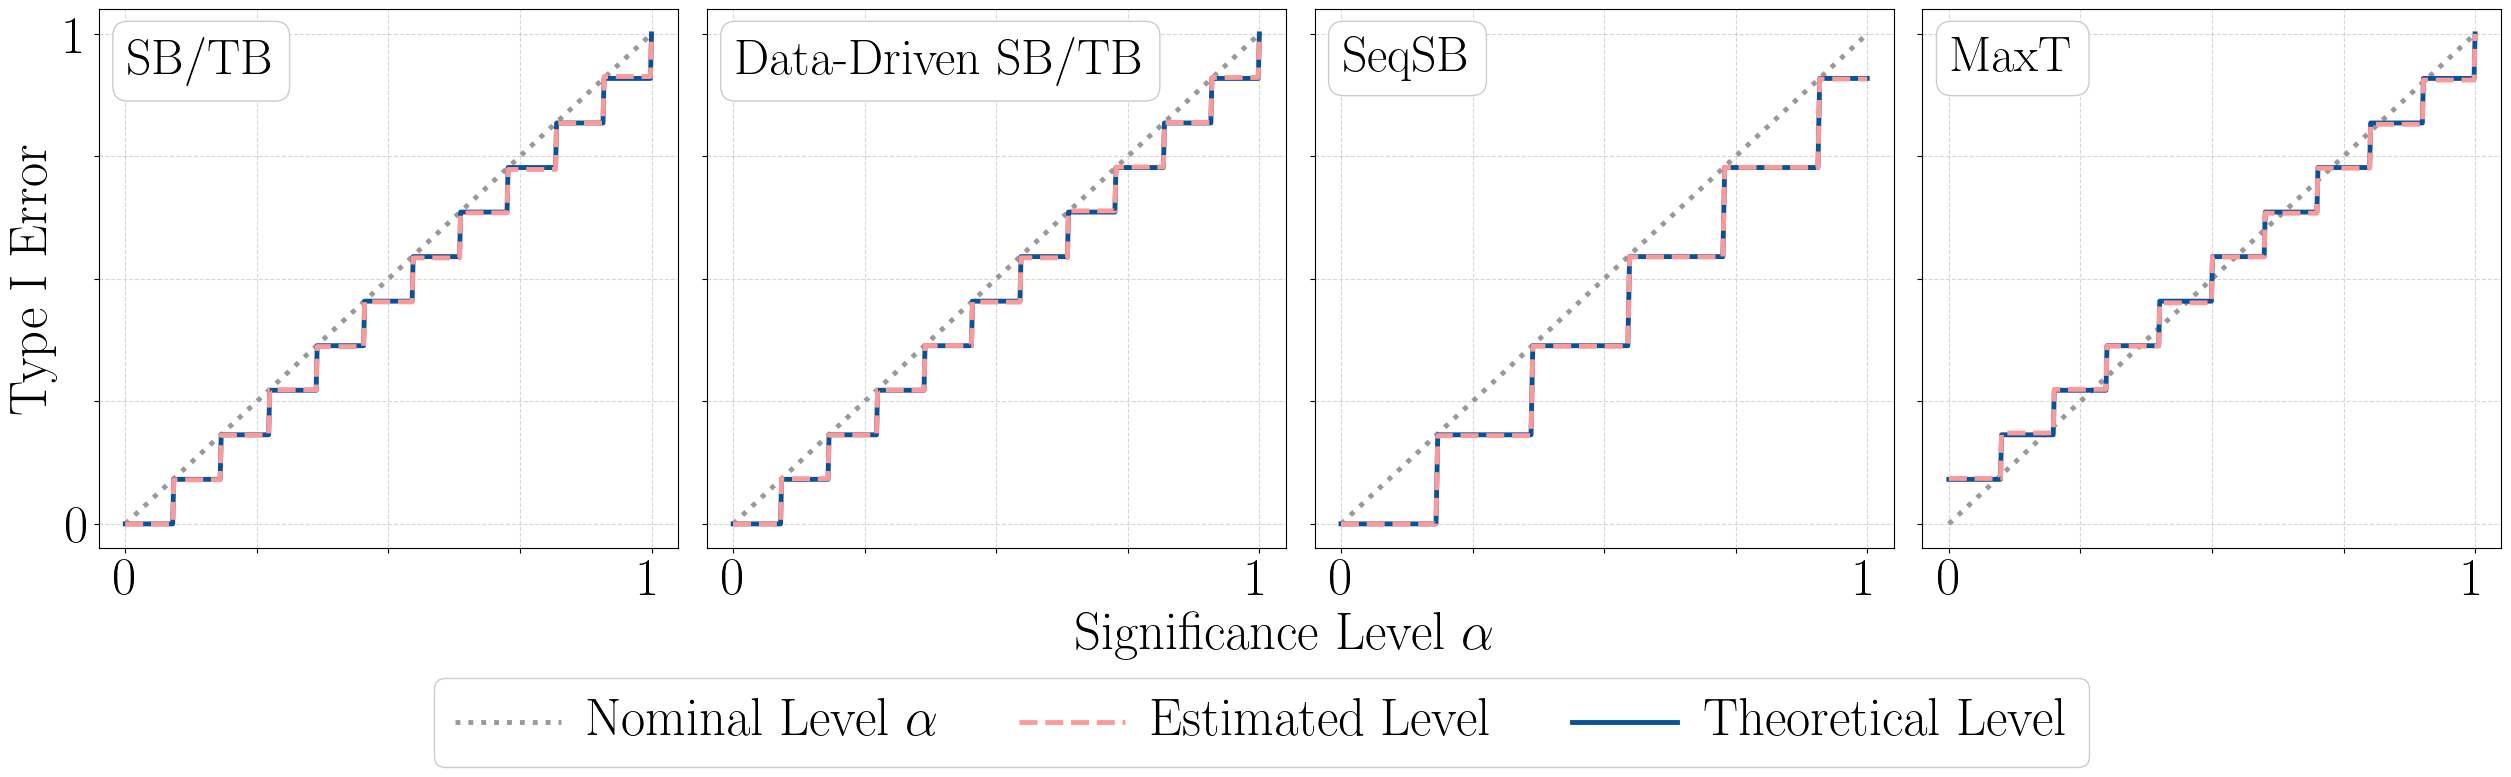

In [2]:
import numpy as np
import os
from matplotlib import rc, rcParams
from matplotlib import pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

# Create figures directory if it does not exist
Path("figures_large").mkdir(exist_ok=True, parents=True)

# Parameters for plots
linewidth = 3.5
markersize = 10
ylabel_fontsize = 38
xlabel_fontsize = 38
title_fontsize = 38
legend_fontsize = 38
title_pad = 15
xlabel_pad = 10
ylabel_pad = 6

# https://gist.github.com/thriveth/8560036
colors = [
    "#fb9a99", # red      (0) 
    "#f781bf", # pink     (1)
    "#ff7f00", # orange   (2)
    "#4daf4a", # green    (3)
    "#377eb8", # blue     (4) 
    "#984ea3", # purple   (5)
    "#a65628", # brown    (6)
    "#999999", # grey     (7) 
    "#dede00", # yellow   (8)
    "#08519c", # navy     (9)
]

# Parameters for typography and TeX
fs = ylabel_fontsize
rcParams.update({"font.size": fs})
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)

# Load Results 

# SB Data (Plot 1)
file_sb = 'results/experiment_1_sb.npz'
if not os.path.exists(file_sb):
    raise FileNotFoundError(f"Error: '{file_sb}' not found.")
data_sb = np.load(file_sb)

# TB Data (Plot 2)
file_tb = 'results/experiment_1_tb.npz'
if not os.path.exists(file_tb):
    raise FileNotFoundError(f"Error: '{file_tb}' not found.")
data_tb = np.load(file_tb)

# SeqSB Data (Plot 3)
file_seqsb = 'results/experiment_5a.npz'
if not os.path.exists(file_seqsb):
    raise FileNotFoundError(f"Error: '{file_seqsb}' not found.")
data_seqsb = np.load(file_seqsb)

# MaxT Data (Plot 4)
file_maxt = 'results/experiment_1_maxT.npz'
if not os.path.exists(file_maxt):
    raise FileNotFoundError(f"Error: '{file_maxt}' not found.")
data_maxt = np.load(file_maxt)

# Figure Creation (1x4 Grid)
width = 31
height = 4.25
height = height * 1.4 + 1.05
f, axs = plt.subplots(1, 4, figsize=(width, height), sharex=True, sharey=True)
f.subplots_adjust(wspace=0.05)

ylabel = r"\textrm{Type I Error}"
xlabel = r"\textrm{Significance Level} $\alpha$"

# --- PLOT 1: SB ---
axs[0].plot(data_sb['alphas'], data_sb['alphas'], color=colors[7], linewidth=linewidth, linestyle=':')
axs[0].plot(data_sb['alphas'], data_sb['theoretical_levels'], color=colors[9], linewidth=linewidth, linestyle='-')
axs[0].plot(data_sb['alphas'], data_sb['estimated_levels'], color=colors[0], linewidth=linewidth, linestyle='--')

# --- PLOT 2: TB ---
axs[1].plot(data_tb['alphas'], data_tb['alphas'], color=colors[7], linewidth=linewidth, linestyle=':')
axs[1].plot(data_tb['alphas'], data_tb['theoretical_levels'], color=colors[9], linewidth=linewidth, linestyle='-')
axs[1].plot(data_tb['alphas'], data_tb['estimated_levels'], color=colors[0], linewidth=linewidth, linestyle='--')

# --- PLOT 3: SeqSB ---
axs[2].plot(data_seqsb['alpha_values'], data_seqsb['alpha_values'], color=colors[7], linewidth=linewidth, linestyle=':')
axs[2].plot(data_seqsb['alpha_values'], data_seqsb['theoretical_levels'], color=colors[9], linewidth=linewidth, linestyle='-')
axs[2].plot(data_seqsb['alpha_values'], data_seqsb['empirical_levels'], color=colors[0], linewidth=linewidth, linestyle='--')

# --- PLOT 4: MaxT ---
axs[3].plot(data_maxt['alphas'], data_maxt['alphas'], color=colors[7], linewidth=linewidth, linestyle=':')
axs[3].plot(data_maxt['alphas'], data_maxt['theoretical_levels'], color=colors[9], linewidth=linewidth, linestyle='-')
axs[3].plot(data_maxt['alphas'], data_maxt['estimated_levels'], color=colors[0], linewidth=linewidth, linestyle='--')

# Formatting and Text Boxes
plot_labels = [r"\textrm{SB/TB}", r"\textrm{Data-Driven SB/TB}", r"\textrm{SeqSB}", r"\textrm{MaxT}"]

for i, ax in enumerate(axs):
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(['0', '', '', '', '1'])
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0', '', '', '', '1'])
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Add the text box to the top-left corner
    ax.text(
        0.05, 0.95, plot_labels[i], 
        transform=ax.transAxes, 
        fontsize=title_fontsize-2, 
        verticalalignment='top', 
        horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc', alpha=1.0),
        zorder=5 # Ensures the box renders above the grid lines
    )
    
# Add x-label 
axs[1].set_xlabel(xlabel, fontsize=xlabel_fontsize, labelpad=xlabel_pad)
axs[1].xaxis.set_label_coords(1.0, -0.12)

# Add y-label only to the far-left plot
axs[0].set_ylabel(ylabel, fontsize=ylabel_fontsize, labelpad=ylabel_pad)

# Figure-level Legend

# Create proxy artist handles for the legend
handle_nom = mlines.Line2D([], [], color=colors[7], linewidth=linewidth, linestyle=':')
handle_est = mlines.Line2D([], [], color=colors[0], linewidth=linewidth, linestyle='--')
handle_theo = mlines.Line2D([], [], color=colors[9], linewidth=linewidth, linestyle='-')

legend_handles = [handle_nom, handle_est, handle_theo]
legend_labels = [r"\textrm{Nominal Level} $\alpha$", r"\textrm{Estimated Level}", r"\textrm{Theoretical Level}"]

f.legend(
    legend_handles, legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.24), 
    ncol=3,
    fontsize=legend_fontsize,
    handleheight=0.1,
    labelspacing=0.5,
    columnspacing=1.5,
    handletextpad=0.5,
    frameon=True,
    edgecolor='#cccccc',
    facecolor='white',
    framealpha=1.0
)

save_path = "figures_large/figure_1.pdf"
f.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Figure successfully saved to: {save_path}")

# Experiment 2

('Test Power vs. Signal Sparsity\n($m=n=100$, $D=20000$, $B=199$)', 'Test Power vs. Permutations\n($m=n=1000$, $D=20000$, $d=128$)')
Figure successfully saved to: figures_large/figure_2.pdf


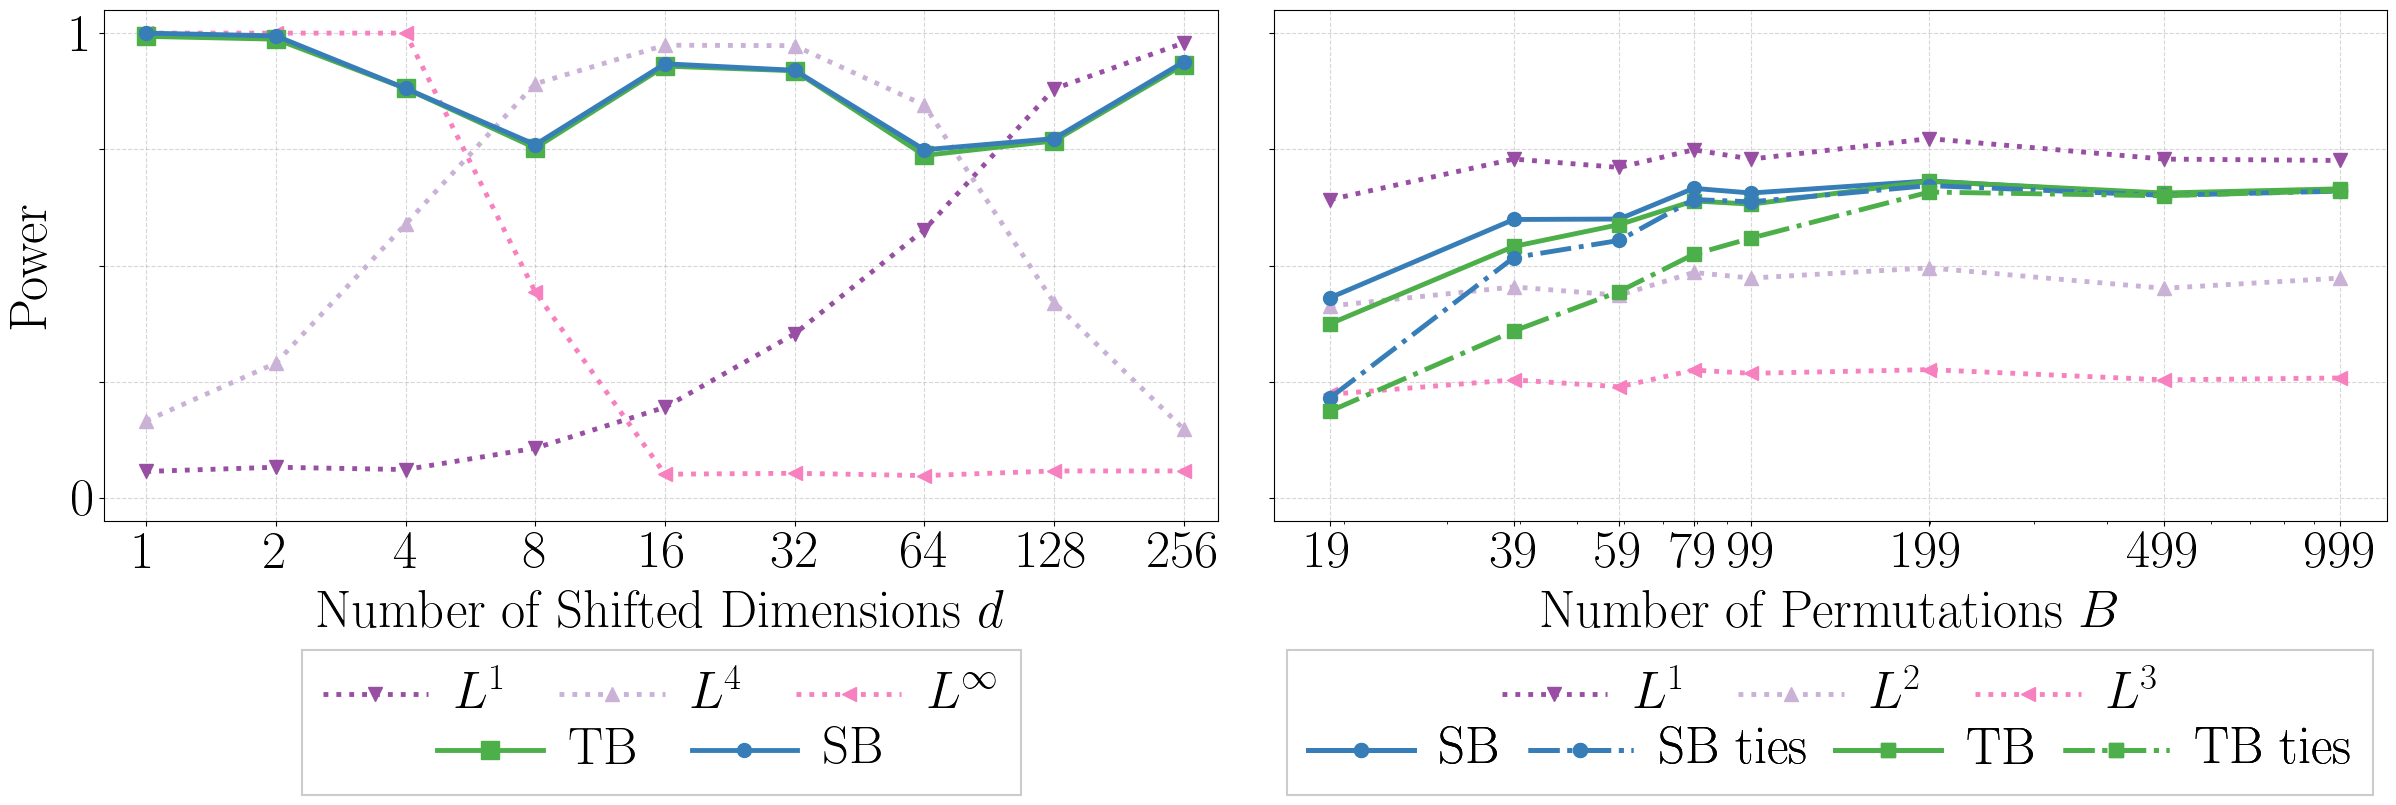

In [3]:
import numpy as np
import os
from matplotlib import rc, rcParams
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Create figures directory if it does not exist
Path("figures_large").mkdir(exist_ok=True, parents=True)

# Parameters for plots
linewidth = 3.5
markersize = 10
ylabel_fontsize = 38
xlabel_fontsize = 38
title_fontsize = 38
legend_fontsize = 38
title_pad = 15
xlabel_pad = 10
ylabel_pad = 10

# Global Font settings for LaTeX rendering
fs = 38
rcParams.update({"font.size": fs})
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)

# Load Results

# LHS Plot Data
data_lhs = np.load('results/experiment_2a.npz')
d_values = data_lhs['d_values']
powers_lhs = [
    data_lhs['l1_powers'],
    data_lhs['l4_powers'],
    data_lhs['linf_powers'],
    data_lhs['sb_powers'],
    data_lhs['tb_powers']
]
m_lhs, D_lhs = int(data_lhs['m']), int(data_lhs['D'])

# RHS Plot Data
data_rhs = np.load('results/experiment_2b.npz')
B_values = data_rhs['B_values']
powers_rhs = [
    data_rhs['l1_powers'],
    data_rhs['l2_powers'],
    data_rhs['l3_powers'],
    data_rhs['sb_t_powers'],
    data_rhs['tb_t_powers'],
    data_rhs['sb_f_powers'],
    data_rhs['tb_f_powers']
]
m_rhs, D_rhs, d_fixed = int(data_rhs['m']), int(data_rhs['D']), int(data_rhs['d_fixed'])

# Styling and Layout Definitions 

# Colors mapped precisely from your example hex palette
color_palette = {
    "blue": "#377eb8",
    "orange": "#ff7f00",
    "red": "#e41a1c",
    "purple": "#984ea3",
    "green": "#4daf4a",
    "pink": "#f781bf",
    "teal": "#cab2d6",
}

# LHS Specifications
labels_lhs = [
    r"$L^1$",
    r"$L^4$",
    r"$L^\infty$",
    r"\textrm{SB}",
    r"\textrm{TB}"
]
colors_lhs = [color_palette["purple"], color_palette["teal"], color_palette["pink"], color_palette["blue"], color_palette["green"]]
markers_lhs = ['v', '^', '<', 'o', 's']
linestyles_lhs = [':', ':', ':', '-', '-']

# RHS Specifications
labels_rhs = [
    r"$L^1$",
    r"$L^2$",
    r"$L^3$",
    r"\textrm{SB}",
    r"\textrm{TB}",
    r"\textrm{SB ties}",
    r"\textrm{TB ties}"
]
colors_rhs = [color_palette["purple"], color_palette["teal"], color_palette["pink"], color_palette["blue"], color_palette["green"], color_palette["blue"], color_palette["green"]]
markers_rhs = ['v', '^', '<', 'o', 's', 'o', 's']
linestyles_rhs = [':', ':', ':', '-', '-', '-.', '-.']

ylabel = r"Power"
xlabels = (
    r"Number of Shifted Dimensions $d$",
    r"Number of Permutations $B$",
)
titles = (
    f"Test Power vs. Signal Sparsity\n($m=n={m_lhs}$, $D={D_lhs}$, $B=199$)",
    f"Test Power vs. Permutations\n($m=n={m_rhs}$, $D={D_rhs}$, $d={d_fixed}$)",
)
print(titles)

# Figure Creation

width = 25
height = 5
height = height * 1.4
f, axs = plt.subplots(1, 2, figsize=(width, height), sharey=True)
f.tight_layout()
f.subplots_adjust(wspace=0.05)

#  LHS Plot
for j in (0,1,2,4,3):
    if j == 4: 
        my_markersize = markersize + 3
    else: 
        my_markersize = markersize
    axs[0].plot(
        d_values,
        powers_lhs[j],
        label=labels_lhs[j],
        color=colors_lhs[j],
        marker=markers_lhs[j],
        linestyle=linestyles_lhs[j],
        linewidth=linewidth,
        markersize=my_markersize,
    )
axs[0].set_xlabel(xlabels[0], fontsize=xlabel_fontsize, labelpad=xlabel_pad)
axs[0].set_ylabel(ylabel, fontsize=ylabel_fontsize, labelpad=ylabel_pad)

axs[0].set_xscale('log', base=2)
axs[0].set_xticks(d_values)
axs[0].set_xticklabels([str(int(d)) for d in d_values])
axs[0].set_xlim([d_values[0] * 0.8, d_values[-1] * 1.2])

axs[0].set_yticks([0, 0.25, 0.5, 0.75, 1])
axs[0].set_ylim(-0.05, 1.05)
axs[0].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axs[0].set_yticklabels(['0', '', '', '', '1'])
axs[0].grid(True, linestyle='--', alpha=0.5)

#  RHS Plot
for j in range(len(powers_rhs)):
    axs[1].plot(
        B_values,
        powers_rhs[j],
        label=labels_rhs[j],
        color=colors_rhs[j],
        marker=markers_rhs[j],
        linestyle=linestyles_rhs[j],
        linewidth=linewidth,
        markersize=markersize,
    )
axs[1].set_xlabel(xlabels[1], fontsize=xlabel_fontsize, labelpad=xlabel_pad)

axs[1].set_xscale('log', base=10)
axs[1].set_xticks(B_values)
axs[1].set_xticklabels([str(int(b)) for b in B_values])
axs[1].set_xlim([B_values[0] * 0.8, B_values[-1] * 1.2])
axs[1].grid(True, linestyle='--', alpha=0.5)

# Formatting & Legends

# Base legend settings
legend_kwargs = {
    "fontsize": legend_fontsize,
    "handleheight": 0.1,
    "labelspacing": 0.5,
    "columnspacing": 1.0, 
    "handletextpad": 0.5,
    "loc": "upper center",
    "frameon": False       
}

legend_kwargs_2 = {
    "fontsize": legend_fontsize,
    "handleheight": 0.1,
    "labelspacing": 0.5,
    "columnspacing": 0.5, 
    "handletextpad": 0.5,
    "loc": "upper center",
    "frameon": False       
}

y_row1 = -0.20
y_row2 = -0.31
y_row3 = -0.47

# --- LHS Legends ---
handles_lhs, labels_lhs = axs[0].get_legend_handles_labels()
leg1_lhs = axs[0].legend(handles_lhs[:3], labels_lhs[:3], ncol=3, bbox_to_anchor=(0.5, y_row1), **legend_kwargs)
axs[0].add_artist(leg1_lhs)
leg2_lhs = axs[0].legend(handles_lhs[3:], labels_lhs[3:], ncol=2, bbox_to_anchor=(0.5, y_row2), **legend_kwargs)

# --- RHS Legends ---
handles_rhs, labels_rhs = axs[1].get_legend_handles_labels()
handles_rhs = handles_rhs[:3] + [handles_rhs[3], handles_rhs[5], handles_rhs[4], handles_rhs[6]]
labels_rhs = labels_rhs[:3] + [labels_rhs[3], labels_rhs[5], labels_rhs[4], labels_rhs[6]]
leg1_rhs = axs[1].legend(handles_rhs[:3], labels_rhs[:3], ncol=3, bbox_to_anchor=(0.5, y_row1), **legend_kwargs)
axs[1].add_artist(leg1_rhs)
leg2_rhs = axs[1].legend(handles_rhs[3:], labels_rhs[3:], ncol=4, bbox_to_anchor=(0.5, y_row2), **legend_kwargs_2)
axs[1].add_artist(leg2_rhs)

# Legend
f.canvas.draw() 

def draw_legend_box(ax, legends):
    """Draws a unified bounding box around a list of legend artists."""
    bboxes = [leg.get_window_extent().transformed(ax.transAxes.inverted()) for leg in legends]
    
    pad_x, pad_y = 0.02, 0.04
    x0 = min(bbox.x0 for bbox in bboxes) - pad_x
    y0 = min(bbox.y0 for bbox in bboxes) - pad_y
    x1 = max(bbox.x1 for bbox in bboxes) + pad_x
    y1 = max(bbox.y1 for bbox in bboxes) + pad_y
    w, h = x1 - x0, y1 - y0
    
    rect = patches.Rectangle(
        (x0 + 0.02, y0 + 0.04), w - 0.04, h - 0.08, 
        transform=ax.transAxes, 
        facecolor='white', 
        edgecolor='#cccccc', 
        linewidth=1.5, 
        clip_on=False, 
        zorder=4 
    )
    ax.add_patch(rect)

draw_legend_box(axs[0], [leg1_lhs, leg2_lhs])
draw_legend_box(axs[1], [leg1_rhs, leg2_rhs])

save_path = "figures_large/figure_2.pdf"
f.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Figure successfully saved to: {save_path}")

# Experiment 3

('\\textrm{Sparse Signal}', '\\textrm{Dense Signal}')
Figure successfully saved to: figures_large/figure_3.pdf


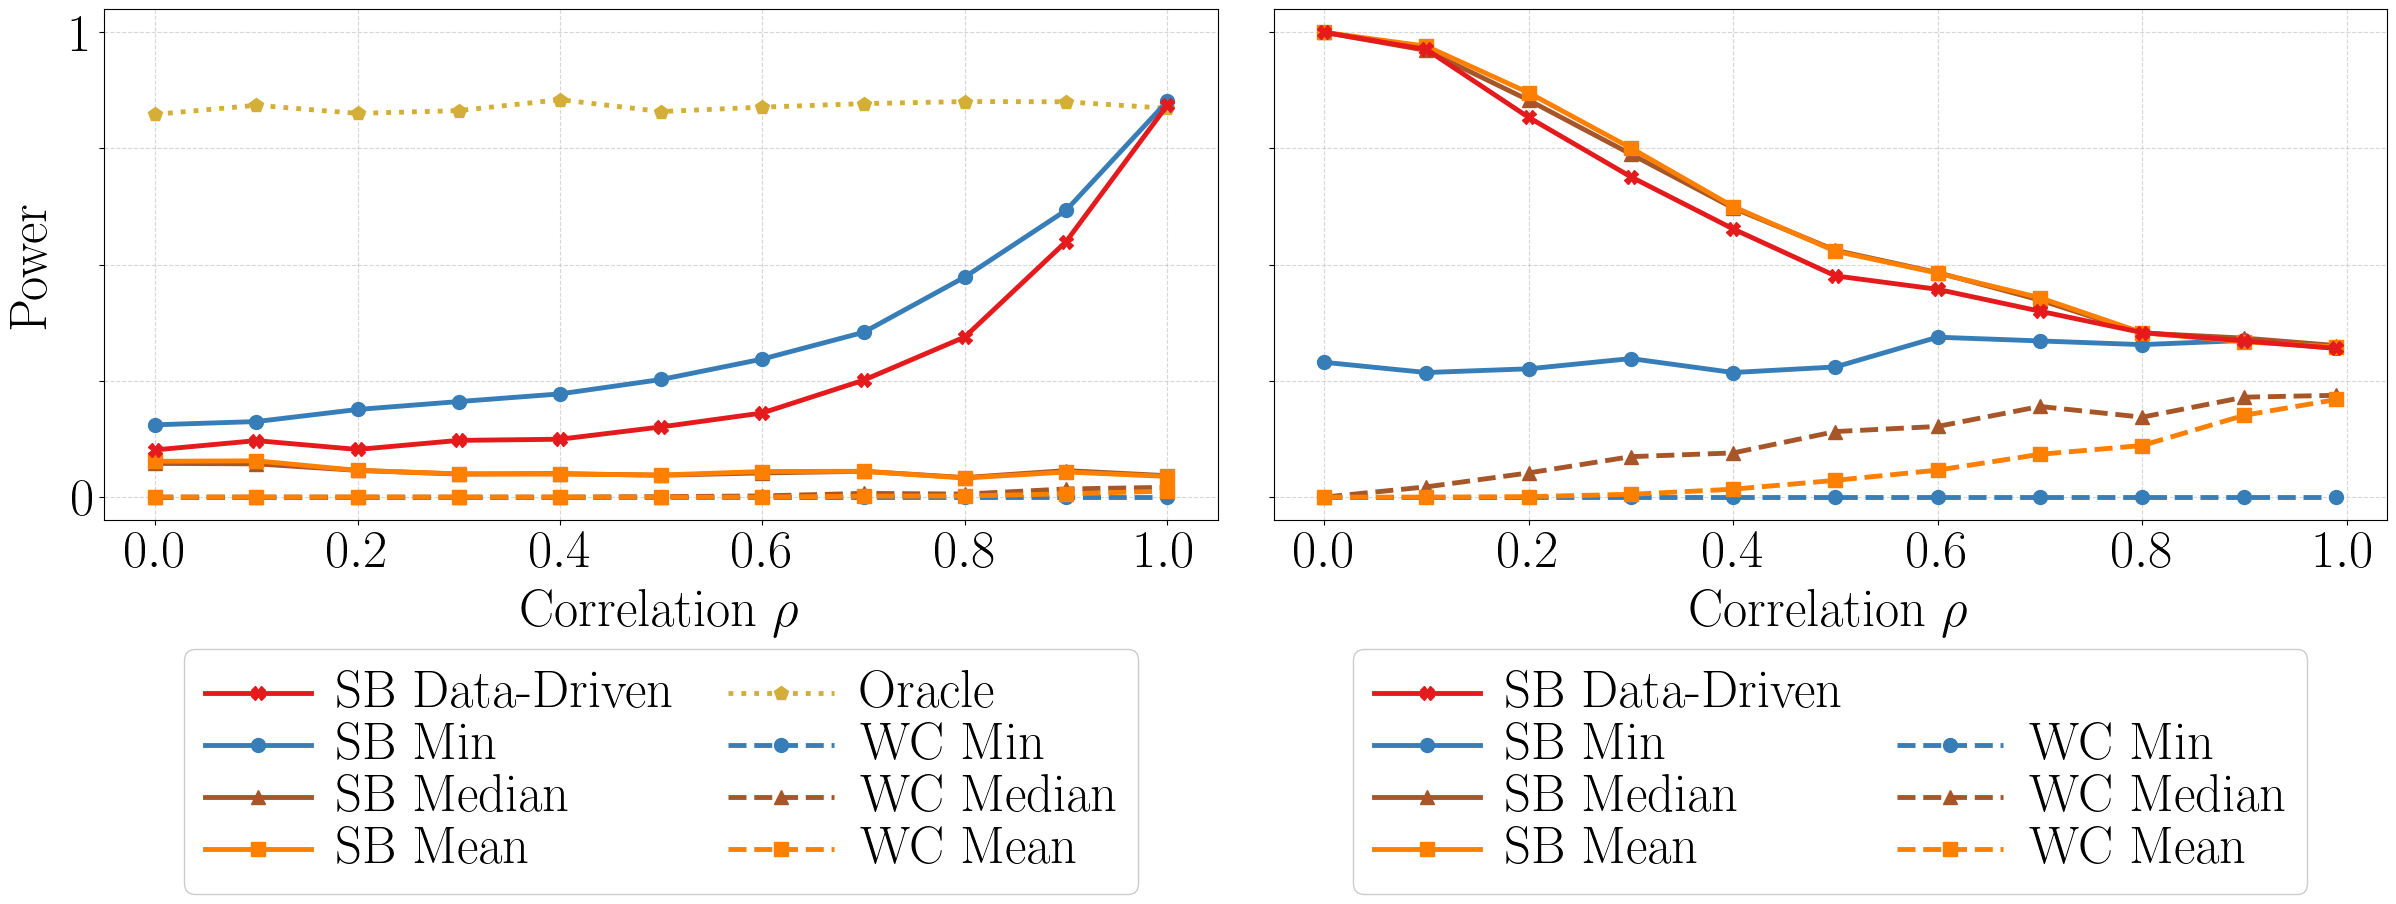

In [4]:
import numpy as np
import os
from matplotlib import rc, rcParams
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Create figures directory if it does not exist
Path("figures_large").mkdir(exist_ok=True, parents=True)

# Parameters for plots
linewidth = 3.5
markersize = 10
ylabel_fontsize = 38
xlabel_fontsize = 38
title_fontsize = 38
legend_fontsize = 38 
title_pad = 15
xlabel_pad = 10
ylabel_pad = 10

# https://gist.github.com/thriveth/8560036
colors = [
    "#e41a1c", # red      (0)
    "#f781bf", # pink     (1)
    "#ff7f00", # orange   (2)
    "#4daf4a", # green    (3)
    "#377eb8", # blue     (4)
    "#984ea3", # purple   (5)
    "#a65628", # brown    (6)
    "#999999", # grey     (7)
    "#d4af37", # yellow   (8)
]

# Parameters for plots
fs = 38
rcParams.update({"font.size": fs})
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)

# Load LHS data (Sparse MVN)
data_lhs = np.load('results/experiment_3a.npz')
rho_lhs = data_lhs['rho_values']
n_lhs, d_lhs, mu_lhs = int(data_lhs['n']), int(data_lhs['d']), float(data_lhs['mu_val'])
res_lhs = {
    'class_1d': data_lhs['class_1d'],
    'wc_min': data_lhs['wc_min'],
    'sb_min': data_lhs['sb_min'],
    'wc_med': data_lhs['wc_med'],
    'sb_med': data_lhs['sb_med'],
    'wc_mean': data_lhs['wc_mean'],
    'sb_mean': data_lhs['sb_mean'],
    'dd_sb': data_lhs['dd_sb']
}

# Load RHS data (Covariance)
data_rhs = np.load('results/experiment_3b.npz')
rho_rhs = data_rhs['rho_values']
n_rhs, d_rhs, mu_rhs = int(data_rhs['n']), int(data_rhs['d']), float(data_rhs['mu_val'])
res_rhs = {
    'wc_min': data_rhs['wc_min'],
    'sb_min': data_rhs['sb_min'],
    'wc_med': data_rhs['wc_med'],
    'sb_med': data_rhs['sb_med'],
    'wc_mean': data_rhs['wc_mean'],
    'sb_mean': data_rhs['sb_mean'],
    'dd_sb': data_rhs['dd_sb']
}

# Configuration for the lines (key, label, color, linestyle, marker)
plot_configs = [
    ('class_1d', r'\textrm{Oracle}', colors[8], ':', 'p'),
    ('wc_min', r'\textrm{WC Min}', colors[4], '--', 'o'),
    ('sb_min', r'\textrm{SB Min}', colors[4], '-', 'o'),
    ('wc_med', r'\textrm{WC Median}', colors[6], '--', '^'),
    ('sb_med', r'\textrm{SB Median}', colors[6], '-', '^'),
    ('wc_mean', r'\textrm{WC Mean}', colors[2], '--', 's'),
    ('sb_mean', r'\textrm{SB Mean}', colors[2], '-', 's'),
    ('dd_sb', r'\textrm{SB Data-Driven}', colors[0], '-', 'X'),
]

ylabel = r"\textrm{Power}"
xlabel = r"\textrm{Correlation} $\rho$"

titles = (
    r"\textrm{Sparse Signal}",
    r"\textrm{Dense Signal}",
)
print(titles)

# Create Figure
width = 25
height = 5
height = height * 1.4
f, axs = plt.subplots(1, 2, figsize=(width, height), sharey=True)
f.tight_layout()
f.subplots_adjust(wspace=0.05)

# Plot LHS
for key, label, color, ls, marker in plot_configs:
    if key in res_lhs:
        axs[0].plot(
            rho_lhs, 
            res_lhs[key], 
            label=label, 
            color=color, 
            marker=marker, 
            linestyle=ls, 
            linewidth=linewidth, 
            markersize=markersize
        )

# Plot RHS
for key, label, color, ls, marker in plot_configs:
    if key in res_rhs:
        axs[1].plot(
            rho_rhs, 
            res_rhs[key], 
            label=label, 
            color=color, 
            marker=marker, 
            linestyle=ls, 
            linewidth=linewidth, 
            markersize=markersize
        )

# Axis formatting
for i in range(2):
    axs[i].set_xlabel(xlabel, fontsize=xlabel_fontsize, labelpad=xlabel_pad)
    axs[i].set_xticks(rho_lhs)
    axs[i].grid(True, linestyle='--', alpha=0.5)

axs[0].set_yticks([0, 0.25, 0.5, 0.75, 1])
axs[0].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0].set_ylim(-0.05, 1.05)
axs[0].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axs[0].set_yticklabels(['0', '', '', '', '1'])
axs[0].set_ylabel(ylabel, fontsize=ylabel_fontsize, labelpad=ylabel_pad)

# Formatting & Legends

# Create a blank, invisible handle to pad rows where necessary
empty_handle = patches.Rectangle((0,0), 0, 0, fill=False, edgecolor='none', visible=False)

# Base legend settings
legend_kwargs = {
    "fontsize": legend_fontsize,
    "handleheight": 0.1,
    "labelspacing": 0.5,
    "columnspacing": 1.0, 
    "handletextpad": 0.5,
    "loc": "upper center",
    "frameon": True,       # Use Matplotlib's native frame
    "edgecolor": '#cccccc',
    "facecolor": 'white',
    "framealpha": 1.0,
    "labelspacing": 0.1
}

#  LHS Legends 
handles_lhs, labels_lhs = axs[0].get_legend_handles_labels()
order_lhs = [
    7, 2, 4, 6,  # Column 1: Oracle, SB Min, SB Med, SB Mean
    0, 1, 3, 5   # Column 2: DD SB,  WC Min, WC Med, WC Mean
]
handles_lhs_ordered = [handles_lhs[i] for i in order_lhs]
labels_lhs_ordered = [labels_lhs[i] for i in order_lhs]
axs[0].legend(handles_lhs_ordered, labels_lhs_ordered, ncol=2, bbox_to_anchor=(0.5, -0.20), **legend_kwargs)

#  RHS Legends 
handles_rhs, labels_rhs = axs[1].get_legend_handles_labels()
handles_rhs_ordered = [
    handles_rhs[6], handles_rhs[1], handles_rhs[3], handles_rhs[5], # Column 1: DD SB, SB Min, SB Med, SB Mean
    empty_handle,   handles_rhs[0], handles_rhs[2], handles_rhs[4]  # Column 2: Empty, WC Min, WC Med, WC Mean
]
labels_rhs_ordered = [
    labels_rhs[6], labels_rhs[1], labels_rhs[3], labels_rhs[5],
    "",            labels_rhs[0], labels_rhs[2], labels_rhs[4]
]

axs[1].legend(handles_rhs_ordered, labels_rhs_ordered, ncol=2, bbox_to_anchor=(0.5, -0.20), **legend_kwargs)

save_path = "figures_large/figure_3.pdf"
f.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Figure successfully saved to: {save_path}")

# Experiment 4

Figure successfully saved to: figures_large/figure_4.pdf


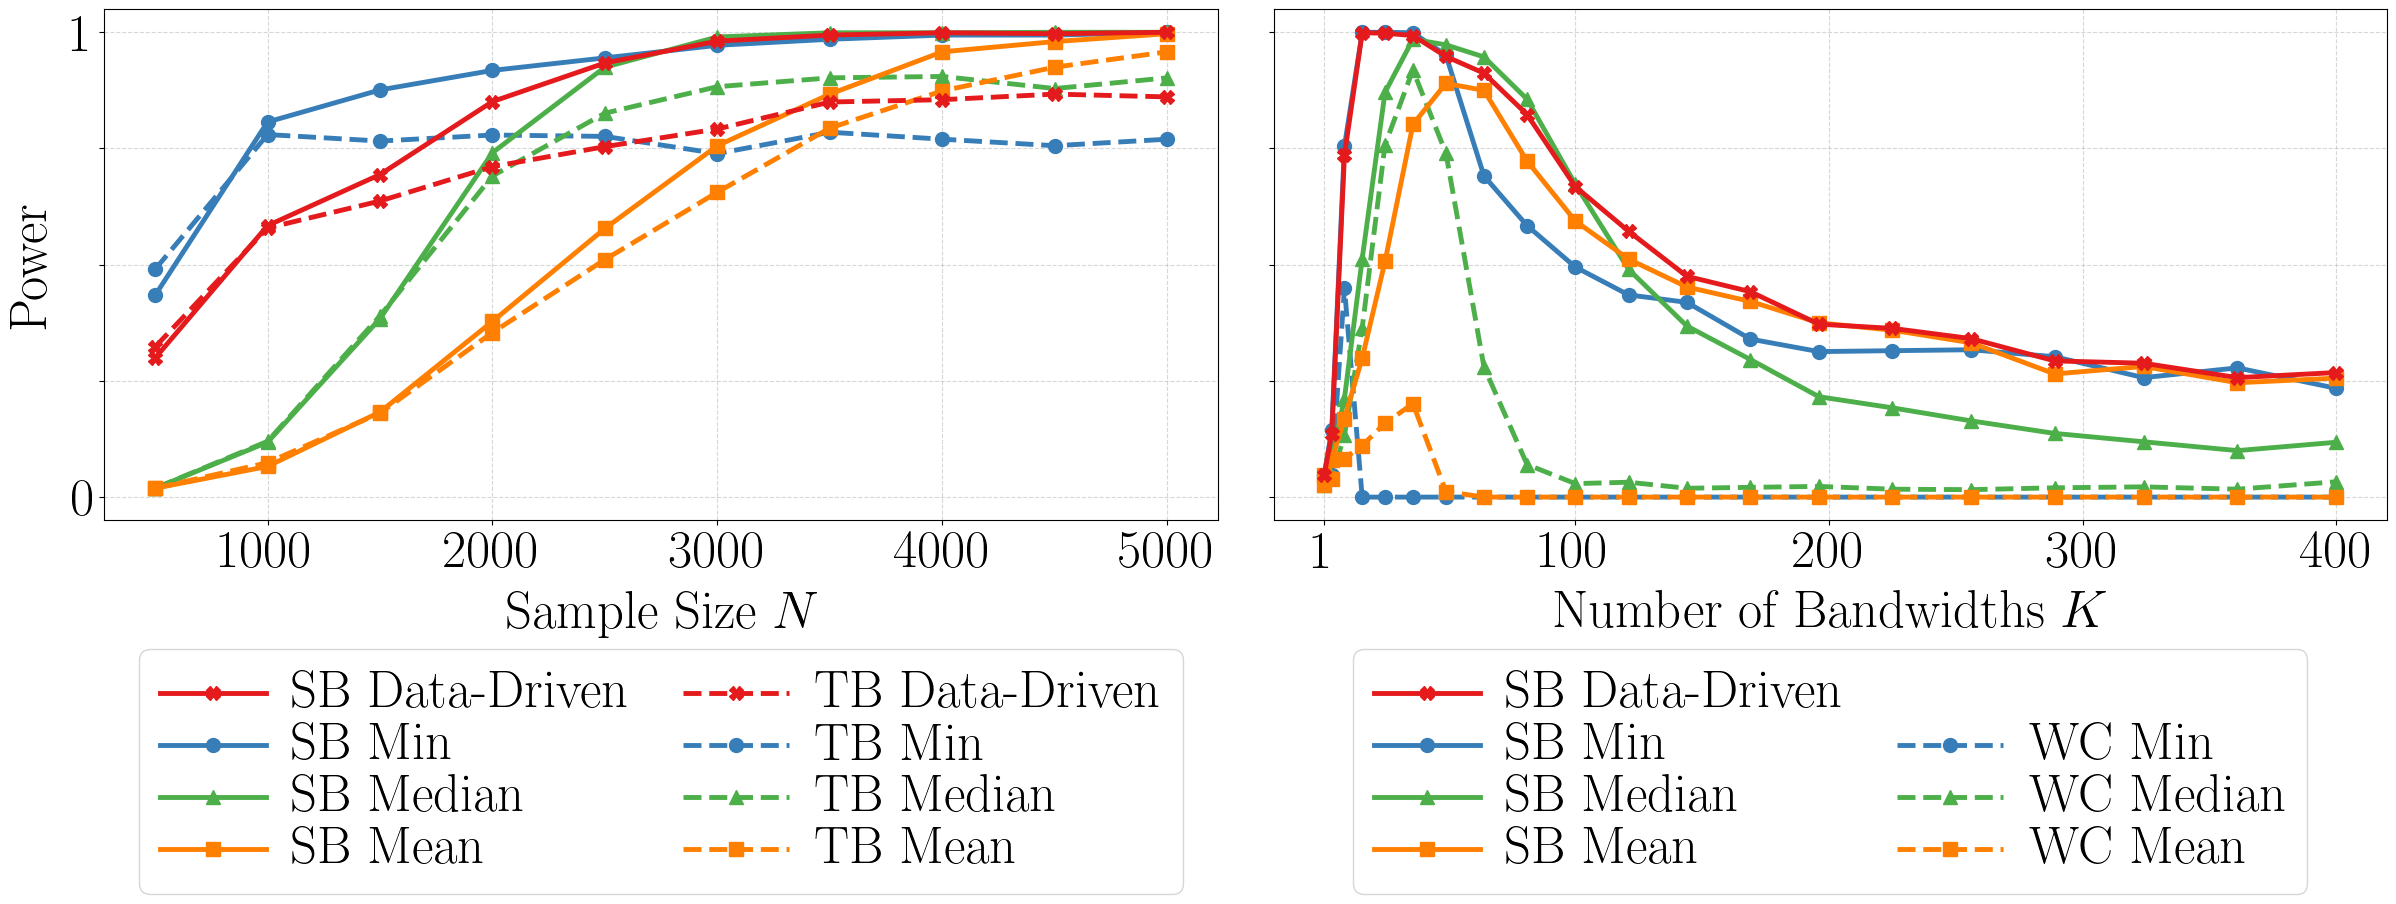

In [5]:
import numpy as np
import os
from matplotlib import rc, rcParams
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Create figures directory if it does not exist
Path("figures_large").mkdir(exist_ok=True, parents=True)

# Parameters for plots
linewidth = 3.5
markersize = 10
ylabel_fontsize = 38
xlabel_fontsize = 38
title_fontsize = 38
legend_fontsize = 38
title_pad = 15
xlabel_pad = 10
ylabel_pad = 10

# https://gist.github.com/thriveth/8560036
colors = [
    "#e41a1c", # red      (0)
    "#f781bf", # pink     (1)
    "#ff7f00", # orange   (2)
    "#4daf4a", # green    (3)
    "#377eb8", # blue     (4)
    "#984ea3", # purple   (5)
    "#a65628", # brown    (6)
    "#999999", # grey     (7)
    "#dede00", # yellow   (8)
]

# Parameters for plots
fs = 38
rcParams.update({"font.size": fs})
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)

# Load Results

# Load LHS Data 
data_lhs = np.load('results/experiment_4a.npz')
n_values = data_lhs['n_values']
d_lhs, c_lhs = int(data_lhs['d']), int(data_lhs['c'])
res_lhs = {
    'sb_min': data_lhs['sb_min'],
    'sb_med': data_lhs['sb_med'],
    'sb_mean': data_lhs['sb_mean'],
    'sb_dd': data_lhs['sb_dd'],
    'tb_min': data_lhs['tb_min'],
    'tb_med': data_lhs['tb_med'],
    'tb_mean': data_lhs['tb_mean'],
    'tb_dd': data_lhs['tb_dd']
}

# Load RHS Data
data_rhs = np.load('results/experiment_4b.npz')
K_values = data_rhs['K_values']
total_bandwidths = [int(k**2) for k in K_values]
n_rhs, d_rhs, c_rhs = int(data_rhs['n']), int(data_rhs['d']), int(data_rhs['c'])
res_rhs = {
    'wc_min': data_rhs['wc_min'],
    'sb_min': data_rhs['sb_min'],
    'wc_med': data_rhs['wc_med'],
    'sb_med': data_rhs['sb_med'],
    'wc_mean': data_rhs['wc_mean'],
    'sb_mean': data_rhs['sb_mean'],
    'sb_dd': data_rhs['sb_dd']
}

# Figure Creation
width = 25
height = 5
height = height * 1.4
f, axs = plt.subplots(1, 2, figsize=(width, height), sharey=True)
f.tight_layout()
f.subplots_adjust(wspace=0.05)

#  LHS Plot
axs[0].plot(n_values, res_lhs['sb_min'], color=colors[4], linestyle='-', marker='o', linewidth=linewidth, markersize=markersize, label=r'\textrm{SB Min}')
axs[0].plot(n_values, res_lhs['tb_min'], color=colors[4], linestyle='--', marker='o', linewidth=linewidth, markersize=markersize, label=r'\textrm{TB Min}')

axs[0].plot(n_values, res_lhs['sb_med'], color=colors[3], linestyle='-', marker='^', linewidth=linewidth, markersize=markersize, label=r'\textrm{SB Median}')
axs[0].plot(n_values, res_lhs['tb_med'], color=colors[3], linestyle='--', marker='^', linewidth=linewidth, markersize=markersize, label=r'\textrm{TB Median}')

axs[0].plot(n_values, res_lhs['sb_mean'], color=colors[2], linestyle='-', marker='s', linewidth=linewidth, markersize=markersize, label=r'\textrm{SB Mean}')
axs[0].plot(n_values, res_lhs['tb_mean'], color=colors[2], linestyle='--', marker='s', linewidth=linewidth, markersize=markersize, label=r'\textrm{TB Mean}')

axs[0].plot(n_values, res_lhs['sb_dd'], color=colors[0], linestyle='-', marker='X', linewidth=linewidth, markersize=markersize, label=r'\textrm{SB Data-Driven}')
axs[0].plot(n_values, res_lhs['tb_dd'], color=colors[0], linestyle='--', marker='X', linewidth=linewidth, markersize=markersize, label=r'\textrm{TB Data-Driven}')

axs[0].set_xlabel(r"\textrm{Sample Size} $N$", fontsize=xlabel_fontsize, labelpad=xlabel_pad)
axs[0].set_ylabel(r"\textrm{Power}", fontsize=ylabel_fontsize, labelpad=ylabel_pad)

axs[0].set_xticks([1000,2000,3000,4000,5000])
axs[0].set_ylim(-0.05, 1.05)
axs[0].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axs[0].set_yticklabels(['0', '', '', '', '1'])
axs[0].grid(True, linestyle='--', alpha=0.5)

# RHS Plot
axs[1].plot(total_bandwidths, res_rhs['sb_min'], color=colors[4], linestyle='-', marker='o', linewidth=linewidth, markersize=markersize, label=r'\textrm{SB Min}')
axs[1].plot(total_bandwidths, res_rhs['wc_min'], color=colors[4], linestyle='--', marker='o', linewidth=linewidth, markersize=markersize, label=r'\textrm{WC Min}')

axs[1].plot(total_bandwidths, res_rhs['sb_med'], color=colors[3], linestyle='-', marker='^', linewidth=linewidth, markersize=markersize, label=r'\textrm{SB Median}')
axs[1].plot(total_bandwidths, res_rhs['wc_med'], color=colors[3], linestyle='--', marker='^', linewidth=linewidth, markersize=markersize, label=r'\textrm{WC Median}')

axs[1].plot(total_bandwidths, res_rhs['sb_mean'], color=colors[2], linestyle='-', marker='s', linewidth=linewidth, markersize=markersize, label=r'\textrm{SB Mean}')
axs[1].plot(total_bandwidths, res_rhs['wc_mean'], color=colors[2], linestyle='--', marker='s', linewidth=linewidth, markersize=markersize, label=r'\textrm{WC Mean}')

axs[1].plot(total_bandwidths, res_rhs['sb_dd'], color=colors[0], linestyle='-', marker='X', linewidth=linewidth, markersize=markersize, label=r'\textrm{SB Data-Driven}')

axs[1].set_xlabel(r"\textrm{Number of Bandwidths} $K$", fontsize=xlabel_fontsize, labelpad=xlabel_pad)
axs[1].set_xticks([1,100,200,300,400])
axs[1].grid(True, linestyle='--', alpha=0.5)

# Formatting & Legends

# Create a blank, invisible handle to pad rows where necessary
empty_handle = patches.Rectangle((0,0), 0, 0, fill=False, edgecolor='none', visible=False)

# Base legend settings
legend_kwargs = {
    "fontsize": legend_fontsize,
    "handleheight": 0.1,
    "labelspacing": 0.5,
    "columnspacing": 1.0, 
    "handletextpad": 0.5,
    "loc": "upper center",
    "frameon": True,       # Use Matplotlib's native frame
    "edgecolor": '#cccccc',
    "facecolor": 'white',
    "labelspacing": 0.1
}

# LHS Legends
handles_lhs, labels_lhs = axs[0].get_legend_handles_labels()
order_lhs = [
    6, 0, 2, 4,  # Column 1: SB (DD, Min, Med, Mean)
    7, 1, 3, 5   # Column 2: TB (DD, Min, Med, Mean)
]
handles_lhs_ordered = [handles_lhs[i] for i in order_lhs]
labels_lhs_ordered = [labels_lhs[i] for i in order_lhs]
axs[0].legend(handles_lhs_ordered, labels_lhs_ordered, ncol=2, bbox_to_anchor=(0.5, -0.20), **legend_kwargs)

# RHS Legends
handles_rhs, labels_rhs = axs[1].get_legend_handles_labels()
handles_rhs_ordered = [
    handles_rhs[6], handles_rhs[0], handles_rhs[2], handles_rhs[4], # Column 1: SB 
    empty_handle,   handles_rhs[1], handles_rhs[3], handles_rhs[5]  # Column 2: WC (with empty row 1)
]
labels_rhs_ordered = [
    labels_rhs[6], labels_rhs[0], labels_rhs[2], labels_rhs[4],
    "",            labels_rhs[1], labels_rhs[3], labels_rhs[5]
]
axs[1].legend(handles_rhs_ordered, labels_rhs_ordered, ncol=2, bbox_to_anchor=(0.5, -0.20), **legend_kwargs)

save_path = "figures_large/figure_4.pdf"
f.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Figure successfully saved to: {save_path}")

# Experiment 5

Figure successfully saved to: figures_large/figure_5.pdf


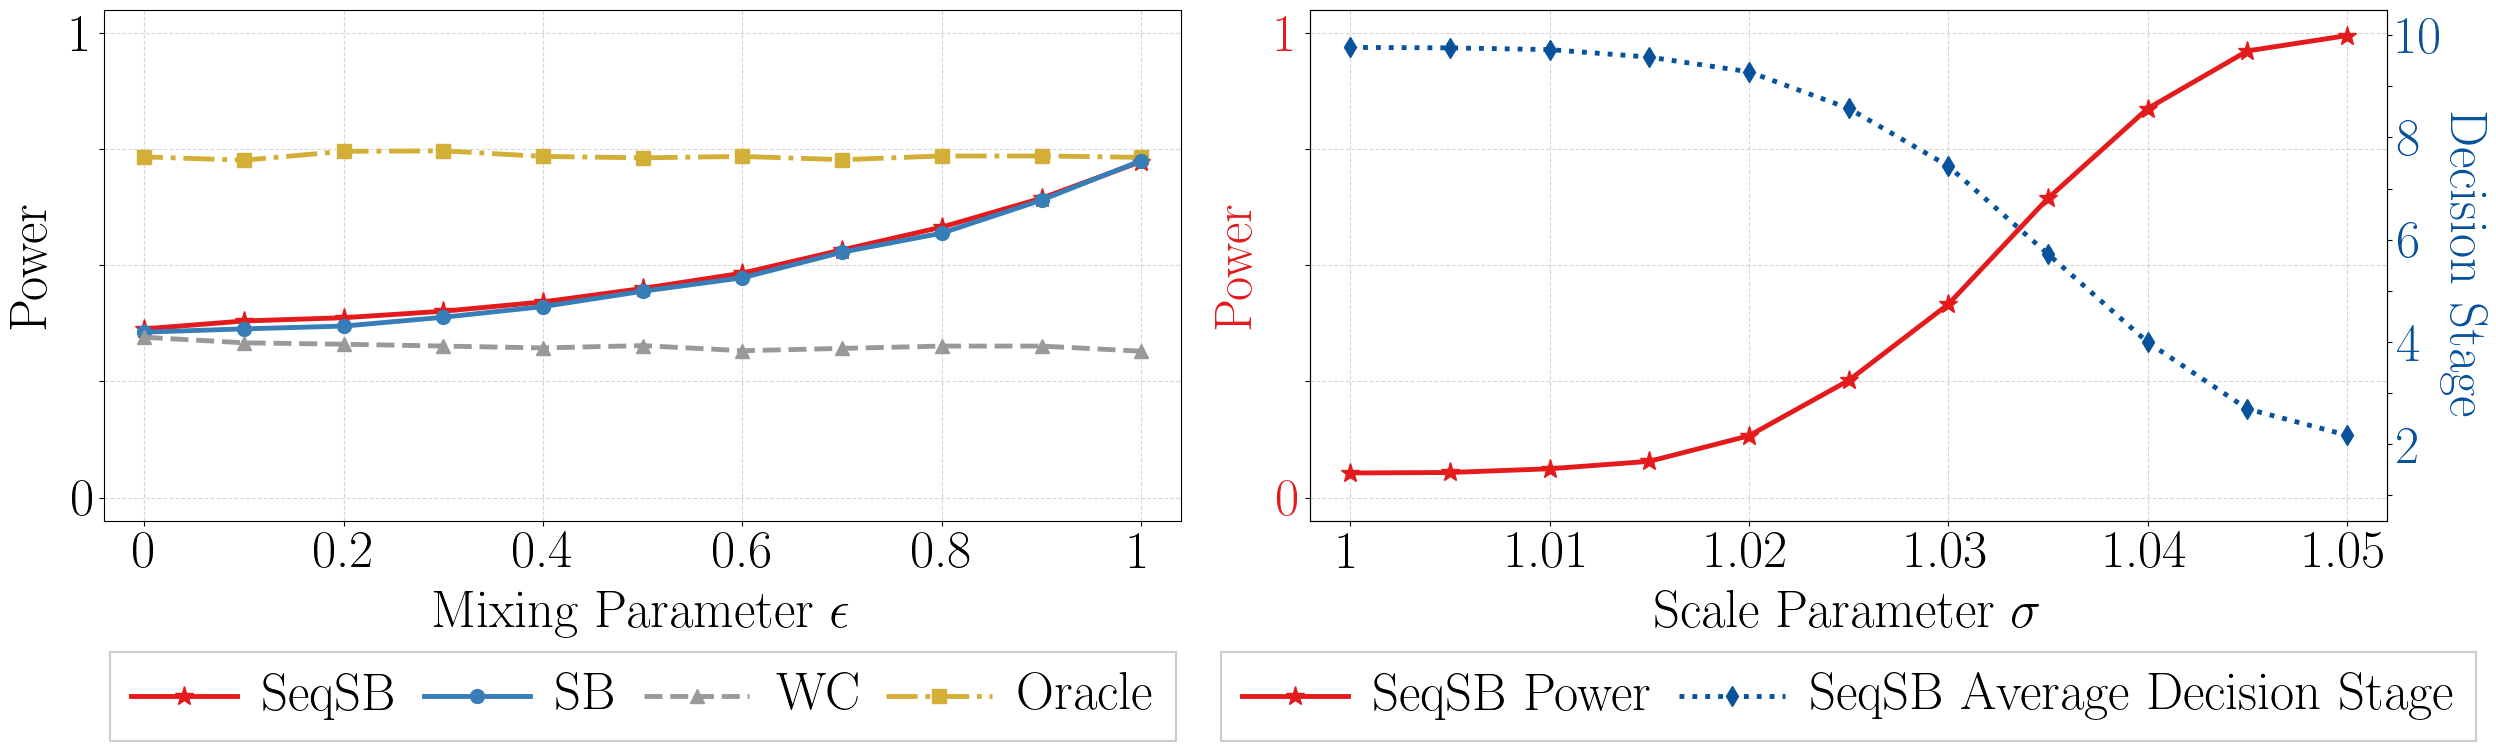

In [6]:
import numpy as np
import os
from matplotlib import rc, rcParams
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Create figures directory if it does not exist
Path("figures_large").mkdir(exist_ok=True, parents=True)

# Parameters for plots
linewidth = 3.5
markersize = 10
size = 38
ylabel_fontsize = size
xlabel_fontsize = size
title_fontsize = size
legend_fontsize = size
title_pad = 15
xlabel_pad = 10
ylabel_pad = 10

# https://gist.github.com/thriveth/8560036
colors = [
    "#e41a1c", # red      (0)
    "#f781bf", # pink     (1)
    "#ff7f00", # orange   (2)
    "#4daf4a", # green    (3)
    "#377eb8", # blue     (4)
    "#984ea3", # purple   (5)
    "#a65628", # brown    (6)
    "#999999", # grey     (7)
    "#d4af37", # yellow   (8)
    "#08519c", # navy     (9)
]

# Parameters for typography and TeX
fs = size
rcParams.update({"font.size": fs})
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)

# Load LHS Data
file_lhs = 'results/experiment_5b.npz'
if not os.path.exists(file_lhs):
    raise FileNotFoundError(f"Error: The file '{file_lhs}' was not found.")
data_lhs = np.load(file_lhs)
eps_values = data_lhs['eps_values']
empirical_power_lhs = data_lhs['empirical_power']
n_lhs, d_lhs, K_lhs = int(data_lhs['n']), int(data_lhs['d']), int(data_lhs['K'])
sigma_lhs = float(data_lhs['sigma'])

# Load RHS Data
file_rhs = 'results/experiment_5c.npz'
if not os.path.exists(file_rhs):
    raise FileNotFoundError(f"Error: The file '{file_rhs}' was not found.")
data_rhs = np.load(file_rhs)
sigma_values = data_rhs['sigma_values']
empirical_power_rhs = data_rhs['empirical_power']
avg_stage = data_rhs['avg_stage']
n_rhs, d_rhs, K_rhs = int(data_rhs['n']), int(data_rhs['d']), int(data_rhs['K'])
epsilon_rhs = float(data_rhs['epsilon'])
include_fail_to_reject = bool(data_rhs['include_fail_to_reject'])

if include_fail_to_reject:
    stage_ylabel = r"\textrm{Decision Stage}" 
    stage_label = r"\textrm{SeqSB Average Decision Stage}"
else:
    stage_ylabel = r"\textrm{Average Decision Stage}" + "\n" + r"\textrm{(Conditioned on Rejection)}"
    stage_label = r"\textrm{Avg Decision Stage (Rej.)}"

# Figure Creation
width = 25
height = 5
height = height * 1.4
f, axs = plt.subplots(1, 2, figsize=(width, height))
f.tight_layout()
f.subplots_adjust(wspace=0.12) 

# LHS Plot
axs[0].plot(1 - eps_values, empirical_power_lhs[:, 0], label=r'\textrm{SeqSB}', color=colors[0], marker='*', linestyle='-', linewidth=linewidth, markersize=markersize+4)
axs[0].plot(1 - eps_values, empirical_power_lhs[:, 3], label=r'\textrm{Oracle}', color=colors[8], marker='s', linestyle='-.', linewidth=linewidth, markersize=markersize)
axs[0].plot(1 - eps_values, empirical_power_lhs[:, 1], label=r'\textrm{SB}', color=colors[4], marker='o', linestyle='-', linewidth=linewidth, markersize=markersize)
axs[0].plot(1 - eps_values, empirical_power_lhs[:, 2], label=r'\textrm{WC}', color=colors[7], marker='^', linestyle='--', linewidth=linewidth, markersize=markersize)

axs[0].set_xlabel(r"\textrm{Mixing Parameter} $\epsilon$", fontsize=xlabel_fontsize, labelpad=xlabel_pad)
axs[0].set_ylabel(r"\textrm{Power}", fontsize=ylabel_fontsize, labelpad=ylabel_pad)

axs[0].set_xlim([-0.04, 1.04])
axs[0].set_ylim([-0.05, 1.05])
axs[0].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
axs[0].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axs[0].set_yticklabels(['0', '', '', '', '1'])
axs[0].set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1'])
axs[0].grid(True, linestyle='--', alpha=0.5)

# RHS Plot

# Axis 1: Power (Red)
axs[1].plot(sigma_values, empirical_power_rhs, color=colors[0], marker='*', linewidth=linewidth, markersize=markersize+4, label=r'\textrm{SeqSB Power}')
axs[1].set_ylabel(r"\textrm{Power}", color=colors[0], fontsize=ylabel_fontsize, labelpad=ylabel_pad)
axs[1].tick_params(axis='y', labelcolor=colors[0])
axs[1].set_xlim([sigma_values[0]-0.0020, sigma_values[-1]+0.0020])
axs[1].set_ylim([-0.05, 1.05])
axs[1].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axs[1].set_yticklabels(['0', '', '', '', '1'])
axs[1].set_xticks([1, 1.01, 1.02, 1.03, 1.04, 1.05])
axs[1].set_xticklabels(['1', '1.01', '1.02', '1.03', '1.04', '1.05'])
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].set_xlabel(r"\textrm{Scale Parameter} $\sigma$", fontsize=xlabel_fontsize, labelpad=xlabel_pad)

# Axis 2: Average Decision Stage (Blue)
ax2 = axs[1].twinx()
ax2.plot(sigma_values, avg_stage, color=colors[9], marker='d', linestyle=':', linewidth=linewidth, markersize=markersize, label=stage_label)
ax2.set_ylabel(stage_ylabel, color=colors[9], fontsize=ylabel_fontsize, labelpad=30, rotation=270)
ax2.tick_params(axis='y', labelcolor=colors[9], labelsize=fs)
ax2.set_yticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
ax2.set_yticklabels(['', '2', '', '4', '', '6', '', '8', '', '10'])
ax2.set_ylim([0.5, K_rhs + 0.5])
ax2.set_yticks(np.arange(1, K_rhs + 1))

# Base legend settings
legend_kwargs = {
    "fontsize": legend_fontsize,
    "handleheight": 0.1,
    "labelspacing": 0.5,
    "columnspacing": 0.5, 
    "handletextpad": 0.5,
    "loc": "upper center",
    "frameon": False       # Keep boxes off, we will draw one unifying box manually
}

y_row1 = -0.205
y_row2 = -0.155

# LHS Legends
handles_lhs, labels_lhs = axs[0].get_legend_handles_labels()
handles_lhs = [handles_lhs[0], handles_lhs[2], handles_lhs[3], handles_lhs[1]]
labels_lhs = [labels_lhs[0], labels_lhs[2], labels_lhs[3], labels_lhs[1]]
leg1_lhs = axs[0].legend(handles_lhs, labels_lhs, ncol=4, bbox_to_anchor=(0.5, y_row1), **legend_kwargs)

# RHS Legends
handles_rhs1, labels_rhs1 = axs[1].get_legend_handles_labels()
handles_rhs2, labels_rhs2 = ax2.get_legend_handles_labels()
handles_rhs = handles_rhs1 + handles_rhs2
labels_rhs = labels_rhs1 + labels_rhs2
leg1_rhs = axs[1].legend(handles_rhs, labels_rhs, ncol=2, bbox_to_anchor=(0.5, y_row1), **legend_kwargs)

# Dynamic Legend Bounding Boxes
f.canvas.draw() 

def draw_legend_box(ax, legends):
    """Draws a unified bounding box around a list of legend artists."""
    bboxes = [leg.get_window_extent().transformed(ax.transAxes.inverted()) for leg in legends]
    
    pad_x, pad_y = 0.02, 0.04
    x0 = min(bbox.x0 for bbox in bboxes) - pad_x
    y0 = min(bbox.y0 for bbox in bboxes) - pad_y
    x1 = max(bbox.x1 for bbox in bboxes) + pad_x
    y1 = max(bbox.y1 for bbox in bboxes) + pad_y
    w, h = x1 - x0, y1 - y0
    
    rect = patches.Rectangle(
        (x0 + 0.02, y0 + 0.04), w - 0.04, h - 0.08, 
        transform=ax.transAxes, 
        facecolor='white', 
        edgecolor='#cccccc', 
        linewidth=1.5, 
        clip_on=False, 
        zorder=4 
    )
    ax.add_patch(rect)

# Draw the dynamic frames
draw_legend_box(axs[0], [leg1_lhs])
draw_legend_box(axs[1], [leg1_rhs])

save_path = "figures_large/figure_5.pdf"
f.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Figure successfully saved to: {save_path}")

# Experiment 6

Figure successfully saved to: figures_large/figure_6.pdf


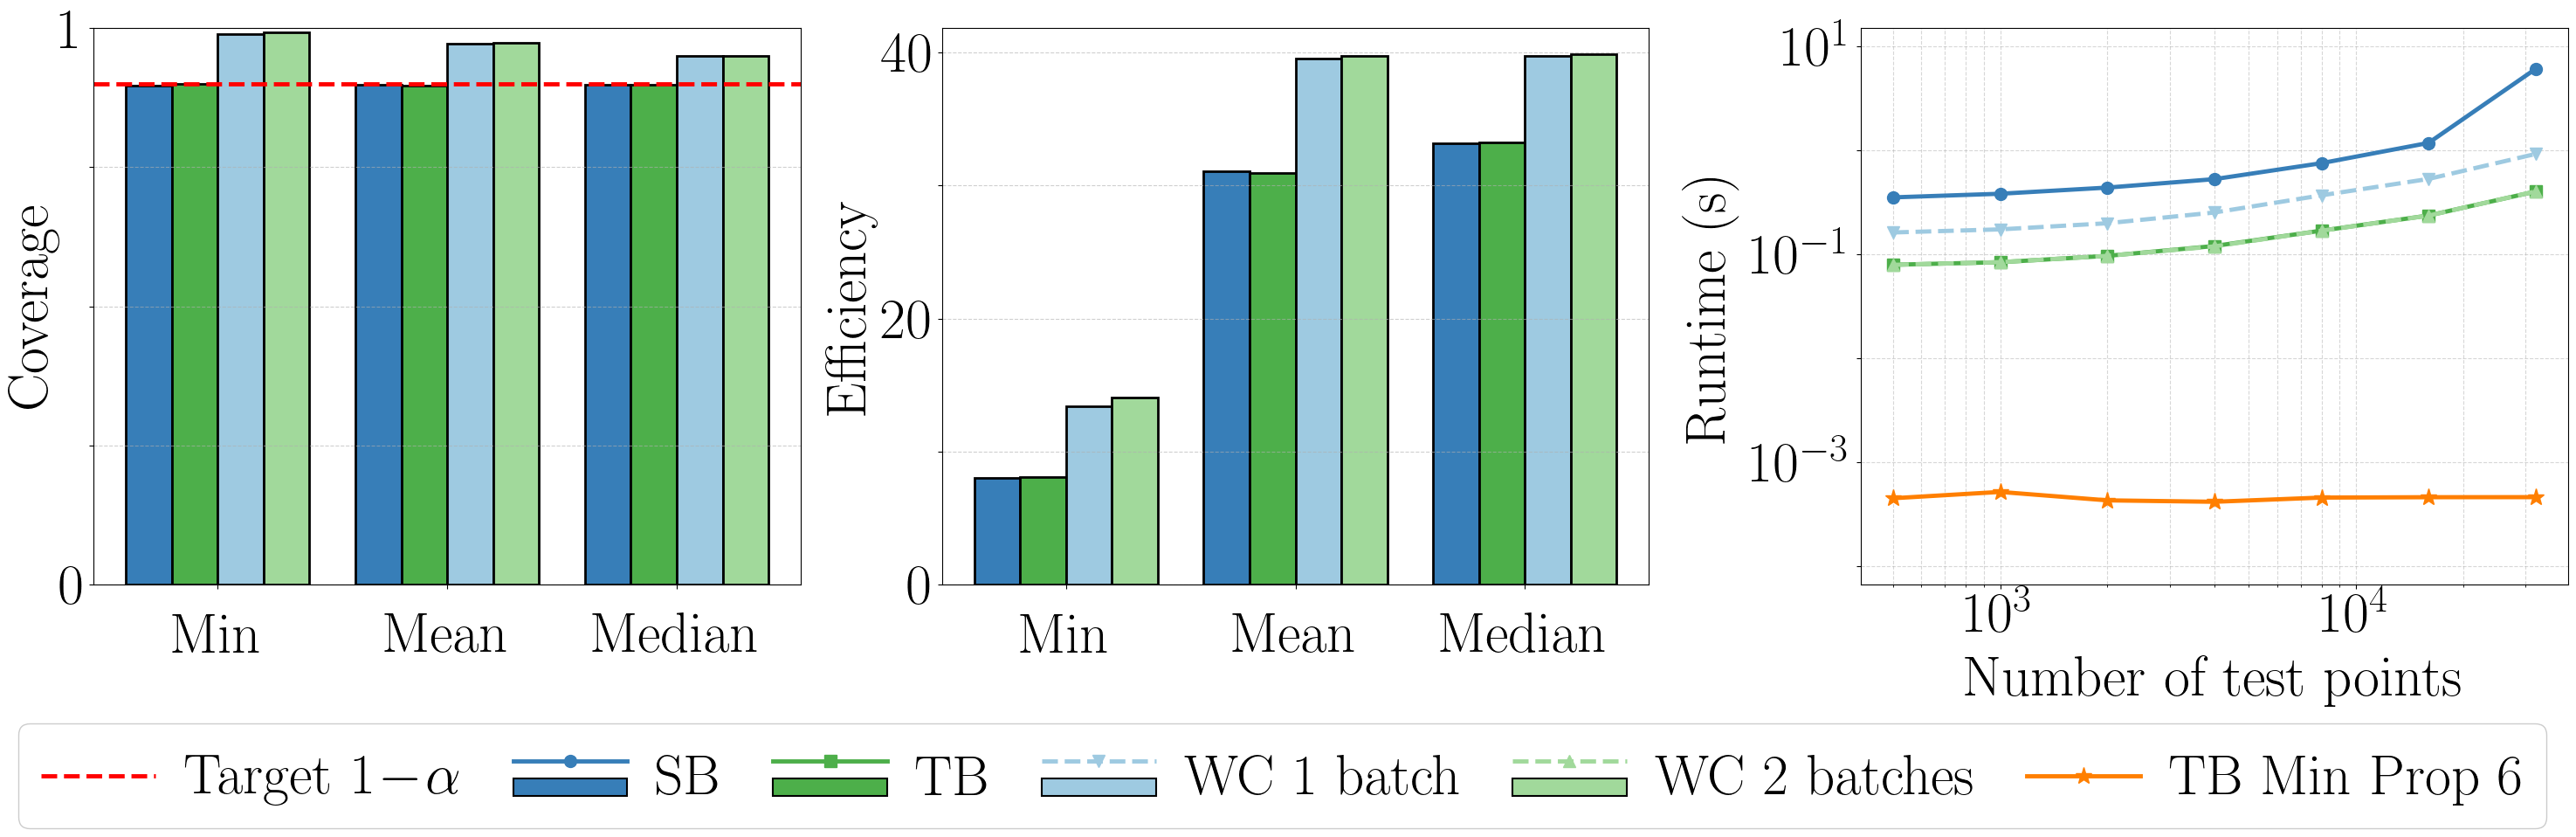

In [7]:
import numpy as np
import os
from matplotlib import rc, rcParams
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from pathlib import Path

# Create figures directory if it does not exist
Path("figures_large").mkdir(exist_ok=True, parents=True)

# Parameters for plots
linewidth = 3.5
markersize = 10
size = 47
ylabel_fontsize = size
xlabel_fontsize = size
title_fontsize = size
legend_fontsize = size
title_pad = 15
xlabel_pad = 10
ylabel_pad = 10

colors = [
    "#e41a1c", # red      (0)
    "#f781bf", # pink     (1)
    "#ff7f00", # orange   (2)
    "#4daf4a", # green    (3)
    "#377eb8", # blue     (4)
    "#984ea3", # purple   (5)
    "#a65628", # brown    (6)
    "#999999", # grey     (7)
    "#dede00", # yellow   (8)
]

fs = size
rcParams.update({"font.size": fs})
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)

# ---------------------------------------------------------
# Load Results: Code 1 (Coverage and Width)
# ---------------------------------------------------------
filepath_6a = 'results/experiment_6a.npz'
if not os.path.exists(filepath_6a):
    raise FileNotFoundError(f"Error: The file '{filepath_6a}' was not found.")

data_6a = np.load(filepath_6a)
agg_functions = data_6a['agg_functions'].tolist()

results_6a = {
    'SB_Cov': data_6a['SB_Cov'],
    'SB_WC_Cov': data_6a['SB_WC_Cov'],
    'TB_Cov': data_6a['TB_Cov'],
    'TB_WC_Cov': data_6a['TB_WC_Cov'],
    'SB_Wid': data_6a['SB_Wid'],
    'SB_WC_Wid': data_6a['SB_WC_Wid'],
    'TB_Wid': data_6a['TB_Wid'],
    'TB_WC_Wid': data_6a['TB_WC_Wid']
}

alpha = float(data_6a['alpha'])

# ---------------------------------------------------------
# Load Results: Code 2 (Execution Times: Varying N_test)
# ---------------------------------------------------------
filepath_6b = 'results/experiment_6b.npz'
if not os.path.exists(filepath_6b):
    raise FileNotFoundError(f"Error: The file '{filepath_6b}' was not found.")

data_6b = np.load(filepath_6b)
n_test_values = data_6b['n_test_values']
times_sb_M = data_6b['times_sb_M']
times_sb_wc_M = data_6b['times_sb_wc_M']
times_tb_M = data_6b['times_tb_M']
times_tb_wc_M = data_6b['times_tb_wc_M']
times_eff_M = data_6b['times_eff_M']

# ---------------------------------------------------------
# Figure Creation (1x3 Grid -> using 5 columns for spacing)
# ---------------------------------------------------------
width = 31
height = 6.2
height = height * 1.4

f = plt.figure(figsize=(width, height))
gs = f.add_gridspec(1, 5, width_ratios=[1, 0.20, 1, 0.30, 1], wspace=0)

axs = [
    f.add_subplot(gs[0]), 
    f.add_subplot(gs[2]), 
    f.add_subplot(gs[4])
]

f.tight_layout()
f.subplots_adjust(wspace=0)

x = np.arange(len(agg_functions))
bar_width = 0.2
xtick_labels_bars = [r"\textrm{Min}", r"\textrm{Mean}", r"\textrm{Median}"]

c_sb_ex = colors[4]  # Blue
c_tb_ex = colors[3]  # Green
c_sb_wc = "#9ecae1"  # Light Blue
c_tb_wc = "#a1d99b"  # Light Green

# --- PLOT 1: Marginal Coverage ---
axs[0].bar(x - 1.5 * bar_width, results_6a['SB_Cov'], bar_width, color=c_sb_ex, edgecolor='black', linewidth=2)
axs[0].bar(x - 0.5 * bar_width, results_6a['TB_Cov'], bar_width, color=c_tb_ex, edgecolor='black', linewidth=2)
axs[0].bar(x + 0.5 * bar_width, results_6a['SB_WC_Cov'], bar_width, color=c_sb_wc, edgecolor='black', linewidth=2)
axs[0].bar(x + 1.5 * bar_width, results_6a['TB_WC_Cov'], bar_width, color=c_tb_wc, edgecolor='black', linewidth=2)

axs[0].axhline(1 - alpha, color='red', linestyle='--', linewidth=linewidth)

axs[0].set_ylabel(r"\textrm{Coverage}", fontsize=ylabel_fontsize, labelpad=0)
axs[0].set_ylim(0, 1)
axs[0].set_xticks(x)
axs[0].set_xticklabels(xtick_labels_bars)
axs[0].tick_params(axis='x', which='major', pad=20)
axs[0].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axs[0].set_yticklabels(['0', '', '', '', '1'])
axs[0].grid(axis='y', linestyle='--', alpha=0.6)

# --- PLOT 2: Average Set Size ---
axs[1].bar(x - 1.5 * bar_width, results_6a['SB_Wid'], bar_width, color=c_sb_ex, edgecolor='black', linewidth=2)
axs[1].bar(x - 0.5 * bar_width, results_6a['TB_Wid'], bar_width, color=c_tb_ex, edgecolor='black', linewidth=2)
axs[1].bar(x + 0.5 * bar_width, results_6a['SB_WC_Wid'], bar_width, color=c_sb_wc, edgecolor='black', linewidth=2)
axs[1].bar(x + 1.5 * bar_width, results_6a['TB_WC_Wid'], bar_width, color=c_tb_wc, edgecolor='black', linewidth=2)

axs[1].set_ylabel(r"\textrm{Efficiency}", fontsize=ylabel_fontsize, labelpad=3)
axs[1].set_xticks(x)
axs[1].set_xticklabels(xtick_labels_bars)
axs[1].tick_params(axis='x', which='major', pad=20)
axs[1].grid(axis='y', linestyle='--', alpha=0.6)
axs[1].set_yticks([0, 10, 20, 30, 40])
axs[1].set_yticklabels(['0', '', '20', '', '40'])

# --- PLOT 3: Varying N_test (Execution Time) ---
axs[2].plot(n_test_values, times_sb_M, color=c_sb_ex, marker='o', linestyle='-', linewidth=linewidth, markersize=markersize)
axs[2].plot(n_test_values, times_tb_M, color=c_tb_ex, marker='s', linestyle='-', linewidth=linewidth, markersize=markersize)
axs[2].plot(n_test_values, times_sb_wc_M, color=c_sb_wc, marker='v', linestyle='--', linewidth=linewidth, markersize=markersize)
axs[2].plot(n_test_values, times_tb_wc_M, color=c_tb_wc, marker='^', linestyle='--', linewidth=linewidth, markersize=markersize)
axs[2].plot(n_test_values, times_eff_M, color=colors[2], marker='*', linestyle='-', linewidth=linewidth, markersize=markersize+4)

axs[2].set_xlabel(r"\textrm{Number of test points}", fontsize=xlabel_fontsize, labelpad=xlabel_pad)
axs[2].set_ylabel(r"\textrm{Runtime (s)}", fontsize=ylabel_fontsize, labelpad=ylabel_pad)

axs[2].set_xscale('log')
axs[2].set_yscale('log')
#axs[2].set_ylim(10 ** (-3) / 4, 10 * 1.5)
axs[2].set_ylim(10 ** (-4) / 1.5, 10 * 1.5)
axs[2].set_yticks([10 ** (-4), 10 ** (-3), 10 ** (-2), 10 ** (-1), 1, 10])
axs[2].set_yticklabels(['', r"$10^{-3}$", '', r"$10^{-1}$", '', r"$10^{1}$"])
axs[2].grid(True, which="both", linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# Custom Explicit Legend Generation (Foolproof)
# ---------------------------------------------------------
class CustomLegendArtist:
    def __init__(self, color, marker, linestyle):
        self.color = color
        self.marker = marker
        self.linestyle = linestyle

class CustomThinBoxLineHandler(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        line_y = ydescent + height * 0.4  
        box_y = ydescent - height * 0.2   
        box_h = height * 0.3              
        
        box = Rectangle((xdescent, box_y), width, box_h, 
                        facecolor=orig_handle.color, edgecolor='black', 
                        linewidth=1.5, transform=trans)
        
        line = Line2D([xdescent, xdescent + width], [line_y, line_y], 
                      color=orig_handle.color, linestyle=orig_handle.linestyle, 
                      linewidth=linewidth, transform=trans)
        
        mark = Line2D([xdescent + width / 2.0], [line_y], 
                      color=orig_handle.color, marker=orig_handle.marker, 
                      markersize=markersize, linestyle='None', transform=trans)
        
        return [box, line, mark]

# --- NEW: Custom Handler for Plain Lines to Control Vertical Placement ---
class CustomPlainLineArtist:
    def __init__(self, color, marker, linestyle, m_size=markersize):
        self.color = color
        self.marker = marker
        self.linestyle = linestyle
        self.m_size = m_size

class CustomPlainLineHandler(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        # Tweak this multiplier (0.4) to shift the plain lines up or down relative to the text
        line_y = ydescent + height * 0.15
        
        line = Line2D([xdescent, xdescent + width], [line_y, line_y], 
                      color=orig_handle.color, linestyle=orig_handle.linestyle, 
                      linewidth=linewidth, transform=trans)
        
        artists = [line]
        
        if orig_handle.marker:
            mark = Line2D([xdescent + width / 2.0], [line_y], 
                          color=orig_handle.color, marker=orig_handle.marker, 
                          markersize=orig_handle.m_size, linestyle='None', transform=trans)
            artists.append(mark)
            
        return artists

# Instantiate handles using our custom wrappers
handle_target = CustomPlainLineArtist('red', None, '--')
handle_tb_min = CustomPlainLineArtist(colors[2], '*', '-', m_size=markersize+4)

handle_sb     = CustomLegendArtist(c_sb_ex, 'o', '-')
handle_tb     = CustomLegendArtist(c_tb_ex, 's', '-')
handle_sb_wc  = CustomLegendArtist(c_sb_wc, 'v', '--')
handle_tb_wc  = CustomLegendArtist(c_tb_wc, '^', '--')

unified_handles = [
    handle_target,
    handle_sb,
    handle_tb,
    handle_sb_wc,
    handle_tb_wc,
    handle_tb_min
]

unified_labels = [
    rf"\textrm{{Target}} $1\!-\!\alpha$",
    r"\textrm{SB}",
    r"\textrm{TB}",
    r"\textrm{WC 1 batch}",
    r"\textrm{WC 2 batches}",
    r"\textrm{TB Min Prop 6}"
]

f.legend(
    unified_handles, unified_labels,
    handler_map={
        CustomLegendArtist: CustomThinBoxLineHandler(),
        CustomPlainLineArtist: CustomPlainLineHandler()
    },
    loc='lower center',
    bbox_to_anchor=(0.49, -0.20),
    ncol=6, 
    fontsize=legend_fontsize,
    handleheight=1.2, # Keeps the box thin and the area compact
    labelspacing=0.5,
    columnspacing=0.9,
    handletextpad=0.5,
    frameon=True,
    edgecolor='#cccccc',
    facecolor='white',
    framealpha=1.0
)

save_path = "figures_large/figure_6.pdf"
f.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Figure successfully saved to: {save_path}")

# Experiment 7

Figure successfully saved to: figures_large/figure_7.pdf


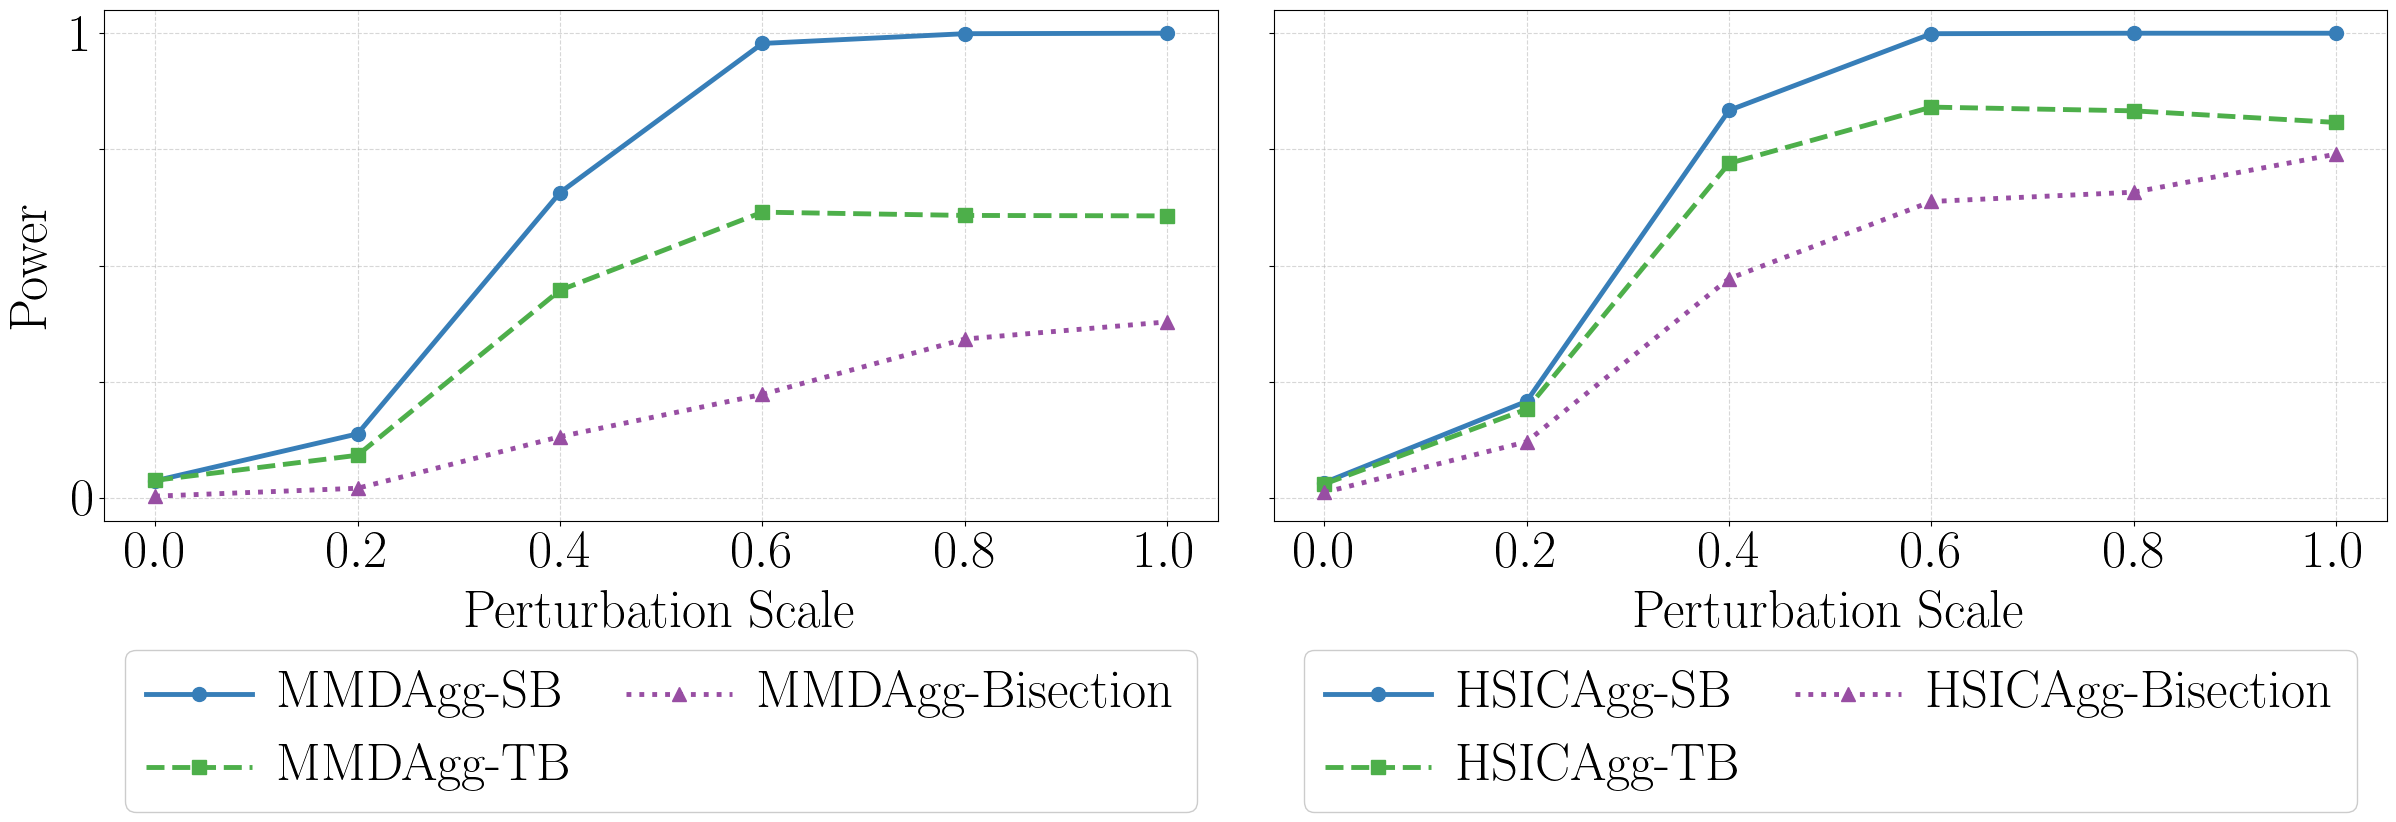

In [8]:
import numpy as np
import os
from matplotlib import rc, rcParams
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Create figures directory if it does not exist
Path("figures_large").mkdir(exist_ok=True, parents=True)

# Parameters for plots
linewidth = 3.5
markersize = 10
ylabel_fontsize = 38
xlabel_fontsize = 38
title_fontsize = 38
legend_fontsize = 38 
title_pad = 15
xlabel_pad = 10
ylabel_pad = 10

# Colors
color_sb = "#377eb8"     # Blue
color_tb = "#4daf4a"     # Green
color_bisect = "#984ea3" # Purple

# Parameters for plots
fs = 38
rcParams.update({"font.size": fs})
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)

# Load LHS data (MMD)
data_lhs = np.load('results/experiment_7a.npz')
scales_lhs = data_lhs['scales']
power_lhs = data_lhs['power'] # Shape: (3, len(scales))

# Load RHS data (HSIC)
data_rhs = np.load('results/experiment_7b.npz')
scales_rhs = data_rhs['scales']
power_rhs = data_rhs['power'] # Shape: (3, len(scales))

# Configuration for the lines (index in power array, label, color, linestyle, marker)
# Indices: 0: Bisection, 1: SB, 2: TB
plot_configs_lhs = [
    (1, r'\textrm{MMDAgg-SB}', color_sb, '-', 'o'),
    (2, r'\textrm{MMDAgg-TB}', color_tb, '--', 's'),
    (0, r'\textrm{MMDAgg-Bisection}', color_bisect, ':', '^'),
]

plot_configs_rhs = [
    (1, r'\textrm{HSICAgg-SB}', color_sb, '-', 'o'),
    (2, r'\textrm{HSICAgg-TB}', color_tb, '--', 's'),
    (0, r'\textrm{HSICAgg-Bisection}', color_bisect, ':', '^'),
]

ylabel = r"\textrm{Power}"
xlabel = r"\textrm{Perturbation Scale}"

# Create Figure
width = 25
height = 5
height = height * 1.4
f, axs = plt.subplots(1, 2, figsize=(width, height), sharey=True)
f.tight_layout()
f.subplots_adjust(wspace=0.05)

# Plot LHS (MMD)
for idx, label, color, ls, marker in plot_configs_lhs:
    axs[0].plot(
        scales_lhs, 
        power_lhs[idx], 
        label=label, 
        color=color, 
        marker=marker, 
        linestyle=ls, 
        linewidth=linewidth, 
        markersize=markersize
    )

# Plot RHS (HSIC)
for idx, label, color, ls, marker in plot_configs_rhs:
    axs[1].plot(
        scales_rhs, 
        power_rhs[idx], 
        label=label, 
        color=color, 
        marker=marker, 
        linestyle=ls, 
        linewidth=linewidth, 
        markersize=markersize
    )

# Axis formatting
for i in range(2):
    axs[i].set_xlabel(xlabel, fontsize=xlabel_fontsize, labelpad=xlabel_pad)
    axs[i].grid(True, linestyle='--', alpha=0.5)

axs[0].set_xticks(scales_lhs)
axs[1].set_xticks(scales_rhs)

axs[0].set_ylim(-0.05, 1.05)
axs[0].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axs[0].set_yticklabels(['0', '', '', '', '1'])
axs[0].set_ylabel(ylabel, fontsize=ylabel_fontsize, labelpad=ylabel_pad)

# Formatting & Legends
legend_kwargs = {
    "fontsize": legend_fontsize,
    "handleheight": 0.1,
    "labelspacing": 0.5,
    "columnspacing": 1.0, 
    "handletextpad": 0.5,
    "loc": "upper center",
    "frameon": True,       
    "edgecolor": '#cccccc',
    "facecolor": 'white',
    "framealpha": 1.0,
}

# LHS Legend 
handles_lhs, labels_lhs = axs[0].get_legend_handles_labels()
axs[0].legend(handles_lhs, labels_lhs, ncol=2, bbox_to_anchor=(0.5, -0.20), **legend_kwargs)

# RHS Legend 
handles_rhs, labels_rhs = axs[1].get_legend_handles_labels()
axs[1].legend(handles_rhs, labels_rhs, ncol=2, bbox_to_anchor=(0.5, -0.20), **legend_kwargs)

save_path = "figures_large/figure_7.pdf"
f.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Figure successfully saved to: {save_path}")